# Étape 1 — Préparation, nettoyage et enrichissement des données

**Projet** : outil de *scoring crédit* pour « Prêt à dépenser » — prédire la probabilité qu'un client ne rembourse pas son crédit.

**Objectif de ce notebook** : à partir des 10 fichiers bruts du jeu de données *Home Credit Default Risk*, produire **un dataset unique, propre et enrichi** (une ligne par client), prêt pour l'entraînement.

**Structure des données** : une table centrale `application_train` (1 ligne = 1 client, avec la cible `TARGET`) et 6 tables satellites décrivant l'historique de chaque client (plusieurs lignes par client), reliées par la clé `SK_ID_CURR`.

**Démarche** :
1. Découverte et analyse de la cible (déséquilibre des classes)
2. Valeurs manquantes
3. Types de variables et détection d'anomalies
4. Encodage des variables catégorielles
5. Feature engineering (ratios métier)
6. Agrégation et fusion des 6 tables satellites
7. Contrôles qualité et sauvegarde

> Les kernels Kaggle de référence (dossier `notebooks/`) ont été analysés et adaptés, notamment pour le feature engineering des tables satellites.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Nombre de lignes à charger pendant qu'on construit le notebook.
# On mettra None à la fin pour tout charger.
NROWS = None

### Chargement du train

In [2]:
app_train = pd.read_csv("../data/application_train.csv", nrows=NROWS)

print("Dimensions :", app_train.shape)
app_train.head()

Dimensions : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Analyse de la target

In [3]:
# Compter combien de 0 et de 1 dans la cible
print(app_train["TARGET"].value_counts())

# Les mêmes chiffres, mais en proportion (pourcentage)
print(app_train["TARGET"].value_counts(normalize=True))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


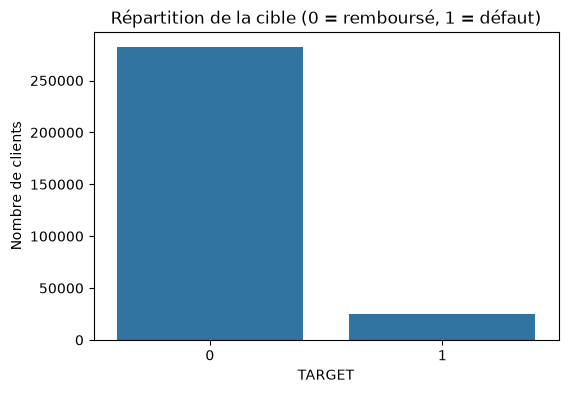

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x="TARGET", data=app_train)
plt.title("Répartition de la cible (0 = remboursé, 1 = défaut)")
plt.xlabel("TARGET")
plt.ylabel("Nombre de clients")
plt.show()

On a un bon déséquilibre de classe, on ne pourra pas juger le modèle sur la simple « exactitude » (accuracy) → on utilisera l'AUC, le recall, etc.

Il faudra rééquilibrer l'apprentissage (class_weight, SMOTE…) et créer un score métier (un faux négatif coûte 10× un faux positif).

### Les valeurs manquantes

In [5]:
# Nombre de valeurs manquantes par colonne
manquantes = app_train.isnull().sum()

# En pourcentage, et trié du plus au moins vide
pct_manquantes = (manquantes / len(app_train) * 100).sort_values(ascending=False)

# Afficher les 15 colonnes les plus incomplètes
pct_manquantes.head(15)


COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
dtype: float64

La variable la moins renseigné contient quand même 30% de valeurs renseignées, ce qui n'est pas rien. Les modèles à base d'arbres savent gérer les `NaN` nativement. Les modèles linéaires eux refusent les `NaN`. On conserve donc les colonnes malgré leurs valeurs manquantes ; l'imputation sera gérée à l'étape de modélisation, en fonction de l'algorithme.

L'énoncé recommande l'outil missingno pour voir les trous d'un coup d'œil

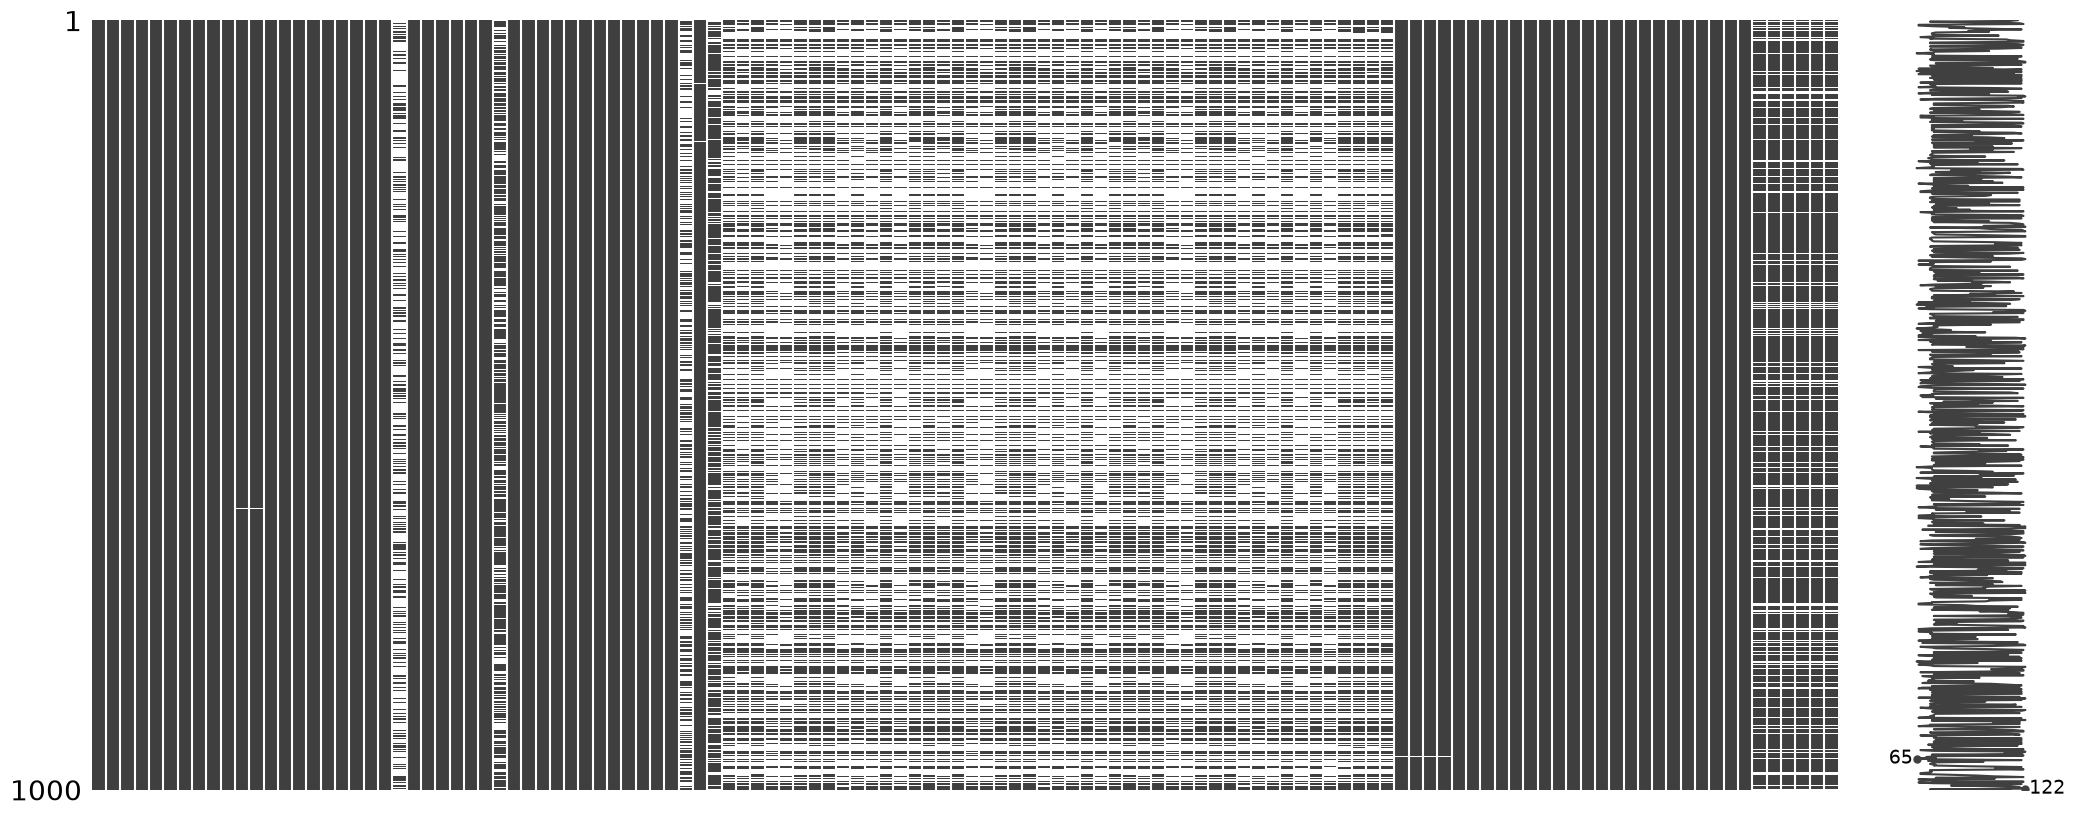

In [6]:
msno.matrix(app_train.sample(1000))
plt.show()

Observations;
- toute la partie gauche est bien noire, ces variables (identité, revenu, montant du crédit...) sont quasi complètes
- le bloc central rayé de blanc correspond à des colonnes qui décrivent le logement (COMMONAREA, LIVINGAPARTMENTS, FLOORSMIN, OWN_CAR_AGE…). Elles manquent souvent ensemble (lorsque l'on ne connait pas le logement, on ignore tous ses détails)

### Type de variables & détection d'anomalies

In [7]:
# Combien de colonnes de chaque type ?
print(app_train.dtypes.value_counts())

float64    65
int64      41
str        16
Name: count, dtype: int64


In [8]:
# On isole les colonnes de type texte, puis on compte les valeurs uniques de chacune
colonnes_texte = app_train.select_dtypes(exclude=["number", "bool"]).columns
app_train[colonnes_texte].nunique().sort_values()


NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
CODE_GENDER                    3
HOUSETYPE_MODE                 3
FONDKAPREMONT_MODE             4
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_INCOME_TYPE               8
OCCUPATION_TYPE               18
ORGANIZATION_TYPE             58
dtype: int64

In [9]:
# On travaille sur une copie, pour garder app_train intact en cas d'erreur
df = app_train.copy()

# Transforme toutes les colonnes texte en colonnes 0/1 (one-hot)
df = pd.get_dummies(df, columns=colonnes_texte, dummy_na=False)

print("Avant encodage :", app_train.shape)
print("Après encodage :", df.shape)


Avant encodage : (307511, 122)
Après encodage : (307511, 246)


Inspectons les colonnes `DAYS_`

In [10]:
app_train[["DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION"]].describe()

,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION
count,307511.000000,307511.000000,307511.000000
mean,-16036.995067,63815.045904,-4986.120328
std,4363.988632,141275.766519,3522.886321
min,-25229.000000,-17912.000000,-24672.000000
25%,-19682.000000,-2760.000000,-7479.500000
50%,-15750.000000,-1213.000000,-4504.000000
75%,-12413.000000,-289.000000,-2010.000000
max,-7489.000000,365243.000000,0.000000


`DAYS_BIRTH` en négatif n'est pas choquant (on revient en arrière vs la date courante jusqu'à la naissance).

Par contre, un max à 365243 pour `DAYS_EMPLOYED` n'est pas possible, cela ferait 100O ans d'ancienneté (!). Combien de clients ont une anomalie pour `DAYS_EMPLOYED` ?

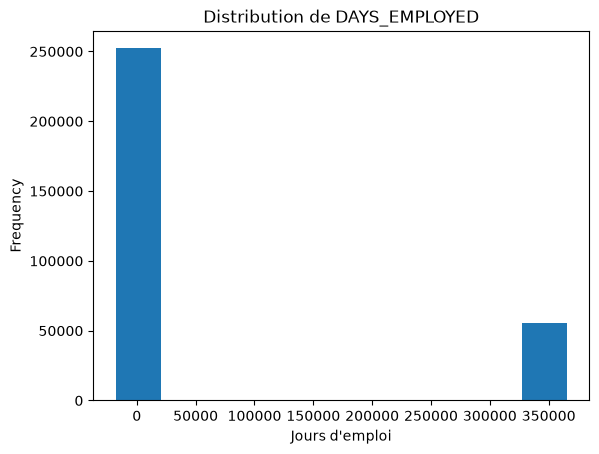

Nombre de clients à 365243 : 55374
Soit 18.0 % des clients


In [11]:
app_train["DAYS_EMPLOYED"].plot.hist(title="Distribution de DAYS_EMPLOYED")
plt.xlabel("Jours d'emploi")
plt.show()

# Combien de clients ont exactement la valeur suspecte ?
nb_anomalies = (app_train["DAYS_EMPLOYED"] == 365243).sum()
print("Nombre de clients à 365243 :", nb_anomalies)
print("Soit", round(nb_anomalies / len(app_train) * 100, 1), "% des clients")

In [12]:
# 1) On garde la trace de l'anomalie dans une nouvelle colonne (potentiellement prédictive)
df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243)

# 2) On remplace la valeur aberrante par NaN
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

# Vérification : plus aucune valeur délirante dans le max
df["DAYS_EMPLOYED"].describe()

count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

### Feature engineering

On reprend ici les 5 ratios du kaggle

In [13]:
df["CREDIT_INCOME_PERC"]  = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"]
df["ANNUITY_INCOME_PERC"] = df["AMT_ANNUITY"]      / df["AMT_INCOME_TOTAL"]
df["PAYMENT_RATE"]        = df["AMT_ANNUITY"]      / df["AMT_CREDIT"]
df["DAYS_EMPLOYED_PERC"]  = df["DAYS_EMPLOYED"]    / df["DAYS_BIRTH"]
df["INCOME_PER_PERSON"]   = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]

# On regarde nos nouvelles colonnes sur les premières lignes
df[["CREDIT_INCOME_PERC", "ANNUITY_INCOME_PERC", "PAYMENT_RATE",
    "DAYS_EMPLOYED_PERC", "INCOME_PER_PERSON"]].head()


,CREDIT_INCOME_PERC,ANNUITY_INCOME_PERC,PAYMENT_RATE,DAYS_EMPLOYED_PERC,INCOME_PER_PERSON
0,0.498036,0.121978,0.060749,0.067329,202500.0
1,0.208736,0.132217,0.027598,0.070862,135000.0
2,0.500000,0.100000,0.050000,0.011814,67500.0
3,0.431748,0.219900,0.094941,0.159905,67500.0
4,0.236842,0.179963,0.042623,0.152418,121500.0


In [14]:
# 1) Y a-t-il des valeurs infinies dans le tableau ?
nb_inf = np.isinf(df.select_dtypes("number")).sum().sum()
print("Nombre de valeurs infinies :", nb_inf)

# 2) On les remplace par NaN, par sécurité
df = df.replace([np.inf, -np.inf], np.nan)

# 3) Contre-vérification
print("Après nettoyage :", np.isinf(df.select_dtypes("number")).sum().sum())

Nombre de valeurs infinies : 0
Après nettoyage : 0


### Fusionner les tables satellites

In [15]:
bureau = pd.read_csv("../data/bureau.csv", nrows=NROWS)

print("Dimensions de bureau :", bureau.shape)

# Combien de lignes par client (SK_ID_CURR) ?
print("\nNombre de crédits passés pour quelques clients :")
print(bureau["SK_ID_CURR"].value_counts().head())


Dimensions de bureau : (1716428, 17)

Nombre de crédits passés pour quelques clients :
SK_ID_CURR
120860    116
169704     94
318065     78
251643     61
425396     60
Name: count, dtype: int64


In [16]:
def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = df.select_dtypes(exclude=["number", "bool"]).columns.tolist()
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

### Stratégie de fusion : agréger puis joindre

Les tables satellites ont **plusieurs lignes par client** (ex. un client peut avoir 36 anciens crédits). On ne peut pas les coller directement sans dupliquer les clients.

La solution : pour chaque table, on **résume** l'historique de chaque client en une seule ligne de statistiques (`min`, `max`, `mean`, `sum`, `count`…) via `groupby("SK_ID_CURR").agg(...)`, puis on **joint** ce résumé à la table centrale avec une jointure `left` (aucun client n'est perdu).

On définit **une fonction par table** (adaptées du kernel Kaggle) : `bureau_and_balance`, `pos_cash`, `installments_payments`, `credit_card_balance`, `previous_applications`.

In [17]:
def bureau_and_balance(num_rows=None, nan_as_category=True):
    bureau = pd.read_csv("../data/bureau.csv", nrows=num_rows)
    bb = pd.read_csv("../data/bureau_balance.csv", nrows=num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)
    # 1) Résumer bureau_balance par crédit (SK_ID_BUREAU), puis le coller à bureau
    bb_aggregations = {"MONTHS_BALANCE": ["min", "max", "size"]}
    for col in bb_cat:
        bb_aggregations[col] = ["mean"]
    bb_agg = bb.groupby("SK_ID_BUREAU").agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how="left", on="SK_ID_BUREAU")
    bureau = bureau.drop(columns=["SK_ID_BUREAU"])
    # 2) Agrégations numériques et catégorielles par client
    num_aggregations = {
        "DAYS_CREDIT": ["min", "max", "mean", "var"],
        "DAYS_CREDIT_ENDDATE": ["min", "max", "mean"],
        "DAYS_CREDIT_UPDATE": ["mean"],
        "CREDIT_DAY_OVERDUE": ["max", "mean"],
        "AMT_CREDIT_MAX_OVERDUE": ["mean"],
        "AMT_CREDIT_SUM": ["max", "mean", "sum"],
        "AMT_CREDIT_SUM_DEBT": ["max", "mean", "sum"],
        "AMT_CREDIT_SUM_OVERDUE": ["mean"],
        "AMT_CREDIT_SUM_LIMIT": ["mean", "sum"],
        "AMT_ANNUITY": ["max", "mean"],
        "CNT_CREDIT_PROLONG": ["sum"],
        "MONTHS_BALANCE_MIN": ["min"],
        "MONTHS_BALANCE_MAX": ["max"],
        "MONTHS_BALANCE_SIZE": ["mean", "sum"],
    }
    cat_aggregations = {}
    for cat in bureau_cat:
        cat_aggregations[cat] = ["mean"]
    for cat in bb_cat:
        cat_aggregations[cat + "_MEAN"] = ["mean"]
    bureau_agg = bureau.groupby("SK_ID_CURR").agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(["BURO_" + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    # 3) Crédits ACTIFS
    active = bureau[bureau["CREDIT_ACTIVE_Active"] == 1]
    active_agg = active.groupby("SK_ID_CURR").agg(num_aggregations)
    active_agg.columns = pd.Index(["ACTIVE_" + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how="left", on="SK_ID_CURR")
    # 4) Crédits CLÔTURÉS
    closed = bureau[bureau["CREDIT_ACTIVE_Closed"] == 1]
    closed_agg = closed.groupby("SK_ID_CURR").agg(num_aggregations)
    closed_agg.columns = pd.Index(["CLOSED_" + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how="left", on="SK_ID_CURR")
    return bureau_agg


In [18]:
def pos_cash(num_rows=None, nan_as_category=True):
    pos = pd.read_csv("../data/POS_CASH_balance.csv", nrows=num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category=True)
    # Statistiques à calculer pour chaque client
    aggregations = {
        "MONTHS_BALANCE": ["max", "mean", "size"],
        "SK_DPD":     ["max", "mean"],   # jours de retard
        "SK_DPD_DEF": ["max", "mean"],   # jours de retard "sérieux"
    }
    for cat in cat_cols:
        aggregations[cat] = ["mean"]
    pos_agg = pos.groupby("SK_ID_CURR").agg(aggregations)
    # Aplatir les noms de colonnes et les préfixer par "POS_"
    pos_agg.columns = pd.Index(["POS_" + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    pos_agg["POS_COUNT"] = pos.groupby("SK_ID_CURR").size()
    return pos_agg

In [19]:
pos = pos_cash(num_rows=NROWS)
print("Dimensions pos :", pos.shape)

df = df.join(pos, how="left", on="SK_ID_CURR")
print("Dimensions df :", df.shape)


Dimensions pos : (337252, 18)
Dimensions df : (307511, 270)


In [20]:
def installments_payments(num_rows=None, nan_as_category=True):
    ins = pd.read_csv("../data/installments_payments.csv", nrows=num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category=True)
    # Features créées au niveau de chaque échéance
    ins["PAYMENT_PERC"] = ins["AMT_PAYMENT"] / ins["AMT_INSTALMENT"]
    ins["PAYMENT_DIFF"] = ins["AMT_INSTALMENT"] - ins["AMT_PAYMENT"]
    ins["DPD"] = (ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]).clip(lower=0)  # retard
    ins["DBD"] = (ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"]).clip(lower=0)  # avance
    aggregations = {
        "NUM_INSTALMENT_VERSION": ["nunique"],
        "DPD": ["max", "mean", "sum"],
        "DBD": ["max", "mean", "sum"],
        "PAYMENT_PERC": ["max", "mean", "sum", "var"],
        "PAYMENT_DIFF": ["max", "mean", "sum", "var"],
        "AMT_INSTALMENT": ["max", "mean", "sum"],
        "AMT_PAYMENT": ["min", "max", "mean", "sum"],
        "DAYS_ENTRY_PAYMENT": ["max", "mean", "sum"],
    }
    for cat in cat_cols:
        aggregations[cat] = ["mean"]
    ins_agg = ins.groupby("SK_ID_CURR").agg(aggregations)
    ins_agg.columns = pd.Index(["INSTAL_" + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    ins_agg["INSTAL_COUNT"] = ins.groupby("SK_ID_CURR").size()
    return ins_agg


In [21]:
ins = installments_payments(num_rows=NROWS)
print("Dimensions ins :", ins.shape)
df = df.join(ins, how="left", on="SK_ID_CURR")
print("Dimensions df :", df.shape)


Dimensions ins : (339587, 26)
Dimensions df : (307511, 296)


In [22]:
def credit_card_balance(num_rows=None, nan_as_category=True):
    cc = pd.read_csv("../data/credit_card_balance.csv", nrows=num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category=True)
    cc = cc.drop(columns=["SK_ID_PREV"])   # on retire cet identifiant, inutile ici
    cc_agg = cc.groupby("SK_ID_CURR").agg(["min", "max", "mean", "sum", "var"])
    cc_agg.columns = pd.Index(["CC_" + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    cc_agg["CC_COUNT"] = cc.groupby("SK_ID_CURR").size()
    return cc_agg

In [23]:
def previous_applications(num_rows=None, nan_as_category=True):
    prev = pd.read_csv("../data/previous_application.csv", nrows=num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category=True)
    # Mêmes valeurs sentinelles 365243 -> NaN que pour DAYS_EMPLOYED
    for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE_1ST_VERSION",
                "DAYS_LAST_DUE", "DAYS_TERMINATION"]:
        prev[col] = prev[col].replace(365243, np.nan)
    prev["APP_CREDIT_PERC"] = prev["AMT_APPLICATION"] / prev["AMT_CREDIT"]
    num_aggregations = {
        "AMT_ANNUITY": ["min", "max", "mean"],
        "AMT_APPLICATION": ["min", "max", "mean"],
        "AMT_CREDIT": ["min", "max", "mean"],
        "APP_CREDIT_PERC": ["min", "max", "mean", "var"],
        "AMT_DOWN_PAYMENT": ["min", "max", "mean"],
        "AMT_GOODS_PRICE": ["min", "max", "mean"],
        "HOUR_APPR_PROCESS_START": ["min", "max", "mean"],
        "RATE_DOWN_PAYMENT": ["min", "max", "mean"],
        "DAYS_DECISION": ["min", "max", "mean"],
        "CNT_PAYMENT": ["mean", "sum"],
    }
    cat_aggregations = {cat: ["mean"] for cat in cat_cols}
    # Stats globales
    prev_agg = prev.groupby("SK_ID_CURR").agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(["PREV_" + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    # Stats sur les demandes ACCEPTÉES
    approved = prev[prev["NAME_CONTRACT_STATUS_Approved"] == 1]
    approved_agg = approved.groupby("SK_ID_CURR").agg(num_aggregations)
    approved_agg.columns = pd.Index(["APPROVED_" + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how="left", on="SK_ID_CURR")
    # Stats sur les demandes REFUSÉES
    refused = prev[prev["NAME_CONTRACT_STATUS_Refused"] == 1]
    refused_agg = refused.groupby("SK_ID_CURR").agg(num_aggregations)
    refused_agg.columns = pd.Index(["REFUSED_" + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how="left", on="SK_ID_CURR")
    return prev_agg


In [24]:
cc = credit_card_balance(num_rows=NROWS)
df = df.join(cc, how="left", on="SK_ID_CURR")
print("Après credit_card :", df.shape)

prev = previous_applications(num_rows=NROWS)
df = df.join(prev, how="left", on="SK_ID_CURR")
print("Après previous_application :", df.shape)


Après credit_card : (307511, 437)
Après previous_application : (307511, 686)


In [25]:
bureau = bureau_and_balance(num_rows=NROWS)
df = df.join(bureau, how="left", on="SK_ID_CURR")
print("Après bureau + bureau_balance :", df.shape)

Après bureau + bureau_balance : (307511, 802)


In [26]:
# 1) Aucun client en double ? (SK_ID_CURR doit être unique)
print("Clients en double :", df["SK_ID_CURR"].duplicated().sum())

# 2) La cible est-elle intacte et toujours déséquilibrée ?
print("\nRépartition de TARGET :")
print(df["TARGET"].value_counts(normalize=True))

# 3) Taille finale
print("\nDimensions :", df.shape)
print("Mémoire :", round(df.memory_usage(deep=True).sum() / 1e6, 1), "Mo")


Clients en double : 0

Répartition de TARGET :
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Dimensions : (307511, 802)
Mémoire : 1793.1 Mo


In [27]:
df.to_parquet("../data/df_prepared.parquet")
print("Dataset sauvegardé dans data/df_prepared.parquet")

Dataset sauvegardé dans data/df_prepared.parquet


## Bilan de l'Étape 1

- **Dataset final** : 307 511 clients × 802 variables, sauvegardé dans `data/df_prepared.parquet` (250 Mo).
- **Cible** : classes déséquilibrées (~7,7 % de défauts) → à traiter en modélisation (`class_weight`/SMOTE, score métier).
- **Anomalies traitées** : `DAYS_EMPLOYED = 365243` → `NaN` (+ drapeau), infinis neutralisés.
- **Encodage** : one-hot des variables nominales.
- **Enrichissement** : ratios métier + agrégation des 6 tables satellites.
- **Choix documenté** : imputation et standardisation **reportées** à l'étape de modélisation (dans une `Pipeline` sklearn, pour éviter le *data leakage*).

➡️ **Prochaine étape** : mise en place du tracking des expérimentations avec MLflow (Étape 2).